# Part 8 — RLHF with PPO: A Walkthrough

## Think of it as a performer rehearsing for the judge, with a coach 🧑‍🏫

Before any code, here's the one picture that explains this entire notebook. Keep it in your head the whole way through:

> After Part 6 the new hire could *imitate* gold answers, and after Part 7 we trained a **judge** that scores any answer. But imitation has a ceiling: the hire only ever copies the one gold answer it was shown, and never finds out whether its *own* phrasing would score higher. **Part 8 puts the hire on stage.** It does a take (generates an answer), the Part-7 judge scores it, and a **coach** nudges the hire to do more of whatever beat expectations — under **two rails**. The rule that matters most: **change gradually, and stay yourself.** Reward a good move, yes — but never let one rehearsal overhaul the whole technique (the **clip**), and never let the hire morph into something unrecognizable just to game the judge (the **KL leash** back to the frozen SFT model).

This is exactly how a sports coach runs film review: watch the rep, compare what happened against what was expected, prescribe a *small* correction — not a brand-new swing every session. PPO is the same idea applied to a language model. Swap a few words and you have the real thing:

| In the rehearsal room | In RLHF-PPO (the code) | Section |
|---|---|---|
| the **performer** doing the take | the **policy** (SFT-initialized `GPTModern`) | 8.1 |
| the performer's **own gut feel** ("that take scores ~7") | the **value head / critic** `Linear(vocab, 1)` | 8.1 |
| **do a take, write down every move** | the **rollout** `generate(...)` + `model_logprobs` (`old_logp`) | 8.2 |
| the **judge** who scores the finished take | the **reward model** (reused from Part 7, frozen) | 8.3 |
| **"don't morph into someone else to game the judge"** | the **KL leash** `r − kl·(logp − ref_logp)` | 8.3 |
| **"was that better than my gut expected?"** | the **advantage** `returns − old_values` | 8.4 |
| **how much more likely is this move now** | the **ratio** `exp(new_logp − old_logp)` | 8.5 |
| **"don't overhaul your technique from one rep"** ⭐ | the **PPO clip** `min(unclipped, clipped)` ⭐ | **8.5 ⭐** |
| the **coach** running one feedback cycle | the **PPO step** in `train_ppo.py` | 8.6 |
| **did the rehearsal actually help?** | `eval_ppo.py` (avg reward vs reference) | 8.7 |

**The two rails** (remember these two words): Rail 1 = *change gradually* (the **clip**, a trust region — one rep shouldn't rewrite your technique); Rail 2 = *stay yourself* (the **KL leash** back to the frozen SFT reference — don't contort into gibberish that games the judge).

**Why this part exists:** Part 6 (SFT) and Part 7 (reward model) are both *static* — the hire imitates a fixed answer, the judge scores a fixed pair. Neither closes the loop. Part 8 **is** the loop: the policy *generates*, the reward model *scores live*, and a policy-gradient update moves the policy toward higher-scoring answers. This is where the judge finally gets off the sidelines.

**What you should know going in:**
- `GPTModern` from **Part 3** — the same decoder LM, now playing the *policy*.
- the chat template (`format_example` / `format_prompt_only`) from **Part 6**.
- the `RewardModel` from **Part 7** — here it is *frozen* and just *used*.
- log-probabilities, one gradient step, and "advantage = actual − expected".

**What you'll build, step by step:**
1. **8.1** the performer + the critic — `PolicyWithValue`
2. **8.2** the rollout — do a take, record every move's log-prob
3. **8.3** the judge scores it + the KL leash
4. **8.4** advantage — "better than my gut expected?"
5. **8.5** the clipped update — `ppo_losses` *(the heart of Part 8)* ⭐
6. **8.6** one full PPO step — `train_ppo.py`, stripped to its spine
7. **8.7** did it improve? — `eval_ppo.py`

**One running example everywhere** — one prompt, carried through every cell:

> **Prompt:** `Summarize why PPO is used in RLHF.`  *(literally the 3rd fallback prompt in `rollout.sample_prompts()`)*

**Important — everything here uses FRESH models, no checkpoints.** Unlike Part 7, we never load SFT/RM weights, so generated text is *gibberish*. That's fine and intended: the **wiring** (rollout → score → shaped reward → advantage → clipped loss → step) is 100% real production code; only the *weights* are random. We say so wherever a cell generates text, so you never mistake gibberish for a bug.


## The Map

Here's the whole rehearsal cycle as a flowchart. You'll see this same diagram at the top of every section, with the step we're on lit up in green and the rest greyed out — so you always know where you are.

```mermaid
graph LR
    prompt["8.2 prompt<br>one instruction"]
    gen["8.2 policy does a take<br>generate + record logprobs"]
    judge["8.3 judge scores it<br>reward model r"]
    shaped["8.3 KL leash<br>r - kl * (logp - ref_logp)"]
    adv["8.4 advantage<br>actual - expected"]
    clip["8.5 clipped update<br>min(unclipped, clipped)"]
    step["8.6 one PPO step<br>backward + AdamW"]
    ev["8.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> gen --> judge --> shaped --> adv --> clip --> step --> ev
    step -. repeat .-> prompt
    ref -. KL leash .-> shaped

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style gen fill:#e8e8e8,stroke:#bbb,color:#777
    style judge fill:#e8e8e8,stroke:#bbb,color:#777
    style shaped fill:#e8e8e8,stroke:#bbb,color:#777
    style adv fill:#e8e8e8,stroke:#bbb,color:#777
    style clip fill:#e8e8e8,stroke:#bbb,color:#777
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#e8e8e8,stroke:#bbb,color:#777
```

Reading it as one rehearsal cycle:
1. **prompt** — hand the performer a question.
2. **take** (8.2) — the policy *generates* an answer and records the log-prob of every token it chose (`old_logp`: "how I played it at take-time").
3. **judge** (8.3) — the frozen Part-7 reward model reads the finished (prompt + answer) and returns one scalar `r`.
4. **KL leash** (8.3) — subtract a penalty for drifting from the frozen SFT reference → the *shaped* reward.
5. **advantage** (8.4) — the critic had a gut estimate (`old_values`); advantage = shaped reward − that = "better than I expected?"
6. **clipped update ⭐** (8.5) — push up the probability of moves with positive advantage, *but clip the step* so one rep can't overhaul the technique.
7. **PPO step** (8.6) — one backward pass + AdamW update on the policy only (the reference never moves).
8. **did it improve?** (8.7) — score the updated policy vs the frozen reference.

**Where this sits in the whole course:** Part 6 taught the hire to imitate; Part 7 built the judge; **Part 8 closes the loop** so the hire optimizes for the judge's approval. Part 9 (GRPO) will simplify this exact loop.

**The single most important idea in this part:** reward what beat expectations — but in *small, clipped* steps, on a *short leash* to the model you started from. Optimization without those two rails collapses into gibberish that games the score.


## Setup

Run this cell once. This notebook lives inside `part_8/`. We add the sibling parts **and the project root** to the import path so the **real** production modules import cleanly — including the namespace import `from part_6.formatters import …` that `rollout.py` does on its own — then fix a seed. We also force the **byte tokenizer** so every token id is a plain, readable byte.


In [ ]:
import sys
from pathlib import Path
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

HERE = Path.cwd()                       # expects to be run from inside part_8/
ROOT = HERE.parent                      # ".../15. Build LLM From Scratch"

# ROOT first: lets `from part_6.formatters import ...` (inside rollout.py) resolve
# as a namespace package. Then the sibling parts so bare-name imports work.
for p in [str(ROOT), str(ROOT/"part_3"), str(ROOT/"part_4"), str(ROOT/"part_6"),
          str(ROOT/"part_7"), str(ROOT/"part_8"), str(HERE)]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Force the byte tokenizer (vocab=256) for visibility: every id is a single byte.
import rollout
rollout._HAS_BPE = False                # flip BPE off so the trace uses readable byte ids

torch.manual_seed(0)
np.set_printoptions(precision=3, suppress=True)

# Tiny dims used by every runnable cell (fresh models, CPU, seconds to run).
V, BLK, NL, NH, NE = 256, 128, 2, 2, 64   # vocab, block_size, n_layer, n_head, n_embd
print("ready — torch", torch.__version__, "| working dir:", HERE.name)
print("NOTE: PAD token id is hard-coded as 2 (model_reward.py & train_ppo.py). With the byte")
print("      tokenizer that is the byte 0x02 — a silent magic number worth remembering.")


### Our running example

We carry one prompt through the whole notebook, so every log-prob, reward, advantage, and clipped-loss value traces back to one thread.


In [ ]:
from rollout import sample_prompts

PROMPT = "Summarize why PPO is used in RLHF."   # 3rd fallback prompt in sample_prompts()
assert PROMPT in sample_prompts(16)              # prove it is the baked-in anchor
print("anchor prompt:", PROMPT)


anchor prompt: Summarize why PPO is used in RLHF.


---
## 8.1 The Performer and the Critic (the Policy)

```mermaid
graph LR
    prompt["8.2 prompt<br>one instruction"]
    gen["8.2 policy does a take<br>generate + record logprobs"]
    judge["8.3 judge scores it<br>reward model r"]
    shaped["8.3 KL leash<br>r - kl * (logp - ref_logp)"]
    adv["8.4 advantage<br>actual - expected"]
    clip["8.5 clipped update<br>min(unclipped, clipped)"]
    step["8.6 one PPO step<br>backward + AdamW"]
    ev["8.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> gen --> judge --> shaped --> adv --> clip --> step --> ev
    step -. repeat .-> prompt
    ref -. KL leash .-> shaped

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style gen fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style judge fill:#e8e8e8,stroke:#bbb,color:#777
    style shaped fill:#e8e8e8,stroke:#bbb,color:#777
    style adv fill:#e8e8e8,stroke:#bbb,color:#777
    style clip fill:#e8e8e8,stroke:#bbb,color:#777
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

> **Part 6 memory:** the SFT model was *just* `GPTModern` — token ids in, next-token logits out, nothing more.
>
> **Part 8 now:** we bolt a tiny **value head** onto the same LM. `PolicyWithValue` returns `(logits, values, loss)`: the LM is the **performer** (it acts), the value head is the **critic** — the performer's own gut estimate of how each position will score.
>
> **Returns later:** Part 9 (GRPO) **deletes this value head entirely** — it replaces the critic's gut estimate with the *average score of a group of takes*. The critic you meet here is exactly the piece Part 9 throws away.

### What we're doing here, and why

A seasoned performer doesn't just act — they *also* have a gut feel for how the take is going. `PolicyWithValue` gives the policy both: the LM produces the action (next-token logits), and `val_head` reads those same logits and emits one scalar "expected score" per position. That's all `policy.py` does — wrap `GPTModern` and add `nn.Linear(vocab_size, 1)`.

### The bookkeeping (optional)

The whole forward pass is three lines (`policy.py`):

```python
logits, loss, _ = self.lm(x, y)              # GPTModern: (B,T,V) logits   (loss=None when y=None)
values = self.val_head(logits).squeeze(-1)   # Linear(V->1) over logits -> (B,T,1) -> squeeze -> (B,T)
return logits, values, loss
```

**Gotcha worth knowing — the critic is a *toy*.** A real value head sits on the LM's **hidden states**; here it sits on the **logits** (`vocab → 1`). The file says so itself: it avoids exposing LM internals to keep the tutorial runnable, at the cost of a crude value estimate. Keep that in mind in 8.4 when advantages look noisy — the baseline is deliberately weak.


In [ ]:
from policy import PolicyWithValue

torch.manual_seed(0)
pol = PolicyWithValue(vocab_size=V, block_size=BLK, n_layer=NL, n_head=NH, n_embd=NE)

x = torch.randint(0, V, (1, 16))             # one fake take, T=16
logits, values, loss = pol(x, None)
print("logits:", tuple(logits.shape))        # (1, 16, 256)
print("values:", tuple(values.shape))        # (1, 16)  <- one gut-estimate per position
print("loss  :", loss)                        # None, since we passed y=None
# Same construction as tests/test_policy_forward.py (B,T,V = 2,16,256).


logits: (1, 16, 256)
values: (1, 16)
loss  : None


### Shape trace

| Stage | Shape |
|---|---|
| input ids `x` | `(1, 16)` |
| `lm(x) → logits` | `(1, 16, 256)` |
| `val_head(logits)` | `(1, 16, 1)` |
| `.squeeze(-1) → values` | `(1, 16)` |

### Why it matters (simple → practical → deeper)

- **Simple:** the policy now both *acts* (logits) and *self-rates* (values).
- **Practical:** the self-rating is the baseline that turns raw rewards into "better-than-expected" signals — that's the whole reason 8.4 can compute an advantage.
- **Deeper:** actor + critic in one network is the classic A2C/PPO design; Part 9 will show you can get the baseline *without* a critic at all.


---
## 8.2 Do a Take, Record Every Move (the Rollout)

```mermaid
graph LR
    prompt["8.2 prompt<br>one instruction"]
    gen["8.2 policy does a take<br>generate + record logprobs"]
    judge["8.3 judge scores it<br>reward model r"]
    shaped["8.3 KL leash<br>r - kl * (logp - ref_logp)"]
    adv["8.4 advantage<br>actual - expected"]
    clip["8.5 clipped update<br>min(unclipped, clipped)"]
    step["8.6 one PPO step<br>backward + AdamW"]
    ev["8.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> gen --> judge --> shaped --> adv --> clip --> step --> ev
    step -. repeat .-> prompt
    ref -. KL leash .-> shaped

    style prompt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style gen fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style judge fill:#e8e8e8,stroke:#bbb,color:#777
    style shaped fill:#e8e8e8,stroke:#bbb,color:#777
    style adv fill:#e8e8e8,stroke:#bbb,color:#777
    style clip fill:#e8e8e8,stroke:#bbb,color:#777
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 7 memory:** the judge read a *finished, human-written* pair. Nothing was generated.
>
> **Part 8 now:** the policy **generates its own answer** with `generate(...)`, then we re-run the model to record `log p(token | context)` for every token it produced — these are `old_logp`, the frozen snapshot of "how likely each move was *at take-time*." This on-policy data (the model's own behavior) is the heart of RLHF.
>
> **Returns later:** Part 9 generates a *group* of takes per prompt instead of one, but this per-token log-prob recording is identical.

### What we're doing here, and why

A performer who wants feedback has to actually *do the take* — and a good coach writes down every move. `rollout.py` does both: format the prompt with the Part-6 template, call `generate`, and use `model_logprobs` to log the probability the policy assigned to each token it chose.

### The bookkeeping (optional)

The causal-LM alignment is the one thing people trip on (`rollout.py`):

```python
def shift_labels(x):  return x[:, 1:].contiguous()        # predict token t+1 from <= t
def gather_logprobs(logits, labels):
    logp = torch.log_softmax(logits, dim=-1)              # (B,T,V) -> all <= 0
    return logp.gather(-1, labels.unsqueeze(-1)).squeeze(-1)   # (B,T): pick the chosen token's logp
def model_logprobs(model, x):
    logits, _, _ = model.lm(x, None)                      # (B,T,V)
    labels = shift_labels(x)                              # (B,T-1)
    return gather_logprobs(logits[:, :-1, :], labels)     # (B,T-1): logp of each NEXT token
```

**The one detail people trip on:** logprobs come out `(B, T-1)`, not `(B, T)`. Position `t`'s logits predict token `t+1`, so we drop the last logit column and the first label. Every mask and reward in 8.6 is shifted by one (`mask[:, 1:]`) to stay aligned. **All logprobs are ≤ 0** (log of a probability).


In [ ]:
from rollout import RLHFTokenizer, format_prompt_only, model_logprobs

tok = RLHFTokenizer(block_size=BLK)          # byte tokenizer (we forced _HAS_BPE=False)
print("vocab_size:", tok.vocab_size)         # 256

prefix = format_prompt_only(PROMPT).replace("</s>", "")
ids = tok.encode(prefix)
x = torch.tensor([ids[-BLK:]], dtype=torch.long)

torch.manual_seed(0)
y = pol.generate(x, max_new_tokens=12, temperature=0.7, top_k=5)   # a take (gibberish: fresh weights)
print("prompt tokens:", x.shape[1], "| generated ids:", y[0].tolist()[x.shape[1]:])
print("decoded take (expected gibberish):", repr(tok.decode(y[0].tolist()[x.shape[1]:])))

old_logp = model_logprobs(pol, y)            # (1, T-1)
print("old_logp shape:", tuple(old_logp.shape), "| all <= 0:", bool((old_logp <= 0).all()))
# 8.5 will compare these old_logp against post-update new_logp to form the ratio.


vocab_size: 256
prompt tokens: 71 | generated ids: [144, 1]
decoded take (expected gibberish): '\x01'
old_logp shape: (1, 72) | all <= 0: True


**Gotcha worth knowing — the take is gibberish, on purpose.** Fresh random weights generate nonsense. We're demonstrating the *plumbing* (generate → record logprobs), not answer quality. With real SFT+RM checkpoints (`orchestrator.py --demo`) the same code produces real answers.

### Why it matters

- **Simple:** you can't coach a take you didn't record.
- **Practical:** `old_logp` is the fixed reference point for the *ratio* — without it there's no clip and no PPO.
- **Deeper:** "learn from your own generations, scored after the fact" is what makes this reinforcement learning rather than supervised learning.


---
## 8.3 The Judge Scores It, and the Leash (Reward + KL)

```mermaid
graph LR
    prompt["8.2 prompt<br>one instruction"]
    gen["8.2 policy does a take<br>generate + record logprobs"]
    judge["8.3 judge scores it<br>reward model r"]
    shaped["8.3 KL leash<br>r - kl * (logp - ref_logp)"]
    adv["8.4 advantage<br>actual - expected"]
    clip["8.5 clipped update<br>min(unclipped, clipped)"]
    step["8.6 one PPO step<br>backward + AdamW"]
    ev["8.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> gen --> judge --> shaped --> adv --> clip --> step --> ev
    step -. repeat .-> prompt
    ref -. KL leash .-> shaped

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style gen fill:#e8e8e8,stroke:#bbb,color:#777
    style judge fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style shaped fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style adv fill:#e8e8e8,stroke:#bbb,color:#777
    style clip fill:#e8e8e8,stroke:#bbb,color:#777
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

> **Part 7 memory:** you *trained* this exact `RewardModel` (encoder → masked-mean → scalar). Here it is **frozen** and just *used*.
>
> **Part 8 now:** the judge scores the finished take into one number `r`. Then comes Rail 2 — the **KL leash**: subtract `kl_coef · (old_logp − ref_logp)`, the per-token gap between the policy and a **frozen copy of the SFT model**. Drift from "yourself" costs reward.
>
> **Returns later:** Part 9 keeps the identical reward model and the identical KL leash — only the baseline (8.4) changes.

### What we're doing here, and why

The judge from Part 7 walks in, reads the *whole* finished take, and writes one number (`RewardModel`: embed → bidirectional encoder → masked-mean pool ignoring PAD id 2 → `Linear(C→1)`). But a performer who'll do *anything* for a high score becomes a fraud. So the coach adds a leash: every token is penalized for straying from the frozen reference's habits. The reward the policy actually optimizes is the **shaped** reward.


### The bookkeeping (optional)

The shaped-reward line, copied from `train_ppo.py`:

```python
kl       = old_logp - ref_logp                       # (N,) per-token policy-vs-reference gap
shaped_r = rewards[:, 1:][act_mask] - kl_coef * kl    # judge score minus the leash penalty
```

As an equation, with $\beta = $ `kl_coef` $= 0.01$:

$$\tilde r_t \;=\; r \;-\; \beta\,\big(\log\pi_\theta(a_t) - \log\pi_{\text{ref}}(a_t)\big)$$

- If the policy matches the reference on a token, the bracket is `0` → no penalty.
- The more the policy *prefers* a token the reference found unlikely, the bigger the penalty.

**The one detail people trip on:** the raw reward `r` is a **single scalar per response**, placed only at the last token (`rewards[i, L-1] = r_scalar`). The KL penalty applies to **every** action token. So `shaped_r` is "mostly leash, with one spike of real reward at the end" — the *episodic, end-only reward* setup.


In [ ]:
from model_reward import RewardModel
from part_6.formatters import Example, format_example   # resolves via ROOT on sys.path (namespace pkg)

torch.manual_seed(0)
rm = RewardModel(vocab_size=V, block_size=BLK, n_layer=NL, n_head=NH, n_embd=NE).eval()

resp = tok.decode(y[0].tolist()[x.shape[1]:])
text = format_example(Example(PROMPT, resp))
z = torch.tensor([tok.encode(text)[:BLK]], dtype=torch.long)
with torch.no_grad():
    r = rm(z)[0].item()
print(f"judge's raw score r = {r:.4f}   (a fresh judge -> basically random)")

# the frozen reference: a deepcopy of the policy, grads off, eval mode
ref = copy.deepcopy(pol)
for p_ in ref.parameters():
    p_.requires_grad_(False)
ref.eval()

ref_logp = model_logprobs(ref, y)
kl_per_token = (old_logp - ref_logp)
print("KL(policy||ref) per-token mean:", float(kl_per_token.mean()),
      "-> ~0 because ref is an identical copy right now")


judge's raw score r = 0.0281   (a fresh judge -> basically random)
KL(policy||ref) per-token mean: 0.0 -> ~0 because ref is an identical copy right now


C:\Users\MSI\AppData\Roaming\Python\Python314\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


**Gotcha worth knowing — at step 0 the leash is slack.** Because `ref` is a *copy* of the policy, `old_logp ≈ ref_logp`, so the KL penalty starts near zero. It only grows as the policy trains away from the reference. That's the leash doing its job: cheap to stay close, increasingly expensive to wander.

### Why it matters

- **Simple:** the judge gives the carrot; the leash stops cheating.
- **Practical:** without the leash, policies reliably discover adversarial gibberish that maxes the reward model — the leash is what keeps answers human-like.
- **Deeper:** the KL term makes this *regularized* policy optimization; it's the mathematical reason the tuned model stays a recognizable descendant of the SFT model.


---
## 8.4 Better Than Expected? (Advantage)

```mermaid
graph LR
    prompt["8.2 prompt<br>one instruction"]
    gen["8.2 policy does a take<br>generate + record logprobs"]
    judge["8.3 judge scores it<br>reward model r"]
    shaped["8.3 KL leash<br>r - kl * (logp - ref_logp)"]
    adv["8.4 advantage<br>actual - expected"]
    clip["8.5 clipped update<br>min(unclipped, clipped)"]
    step["8.6 one PPO step<br>backward + AdamW"]
    ev["8.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> gen --> judge --> shaped --> adv --> clip --> step --> ev
    step -. repeat .-> prompt
    ref -. KL leash .-> shaped

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style gen fill:#e8e8e8,stroke:#bbb,color:#777
    style judge fill:#e8e8e8,stroke:#bbb,color:#777
    style shaped fill:#e8e8e8,stroke:#bbb,color:#777
    style adv fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style clip fill:#e8e8e8,stroke:#bbb,color:#777
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 6/7 memory:** there was no notion of "expectation" — SFT had a fixed target, the RM a fixed pair.
>
> **Part 8 now:** the critic's gut estimate `old_values` becomes a **baseline**. Advantage = `shaped_r − old_values` = "did this take beat what I expected?" Positive → do more of it; negative → less. We then normalize to mean 0, std 1 for a stable gradient.
>
> **Returns later:** this is the line Part 9 changes. GRPO drops `old_values` and uses the **group average reward** as the baseline — same subtraction, different "expected."

### What we're doing here, and why

Coaches don't praise a take in a vacuum — they praise it *relative to expectations*. A 7/10 from someone who usually scores 9 is a *bad* day; a 7 from a beginner is great. Advantage encodes exactly that: subtract the critic's predicted score from what actually happened.

### The bookkeeping (optional)

Copied verbatim from `train_ppo.py`:

```python
returns = shaped_r                                          # episodic: target = immediate shaped reward
adv     = returns - old_values                              # actual minus the critic's gut estimate
adv     = (adv - adv.mean()) / adv.std().clamp_min(1e-6)    # normalize: mean 0, std 1
```

**Gotcha worth knowing — NO GAE, despite the args.** `train_ppo.py` parses `--gamma 1.0` and `--lam 0.95` but **never uses them**. There's no multi-step bootstrapping and no Generalized Advantage Estimation — `returns` is just the immediate shaped reward and `adv` is a one-step difference. The flags are vestigial (and would otherwise imply GAE to anyone who's read the PPO paper).


In [ ]:
# Use the policy's own value head on the take as old_values, and the reward/leash from 8.3.
# (For clarity we trace over ALL positions; 8.6 masks to action tokens only.)
with torch.no_grad():
    _, values_full, _ = pol(y, None)
old_values = values_full[:, :-1].reshape(-1)               # align to logprobs -> (T-1,)

old_logp_flat = old_logp.reshape(-1)
ref_logp_flat = ref_logp.reshape(-1)
shaped_r = r - 0.01 * (old_logp_flat - ref_logp_flat)      # scalar judge reward r minus the leash
returns  = shaped_r
adv      = returns - old_values
adv_norm = (adv - adv.mean()) / adv.std().clamp_min(1e-6)

print("shaped_r  mean/std:", round(float(shaped_r.mean()), 4), round(float(shaped_r.std()), 4))
print("adv (raw) mean/std:", round(float(adv.mean()), 4), round(float(adv.std()), 4))
print("adv (norm)mean/std:", round(float(adv_norm.mean()), 4), round(float(adv_norm.std()), 4))  # ~0, ~1


shaped_r  mean/std: 0.0281 0.0
adv (raw) mean/std: -0.0703 0.3542
adv (norm)mean/std: 0.0 1.0


### Shape trace

Every tensor here is `(T-1,)` (one entry per recorded move; the real loop keeps only the action tokens):

| Tensor | Shape | Meaning |
|---|---|---|
| `old_values` | `(T-1,)` | the critic's expected score per move |
| `shaped_r` / `returns` | `(T-1,)` | judge reward minus the KL leash |
| `adv` | `(T-1,)` | actual − expected |
| `adv_norm` | `(T-1,)` | normalized to mean 0, std 1 |

### Why it matters

- **Simple:** reward what beats expectations, not what's merely good.
- **Practical:** subtracting a baseline slashes gradient variance — the single most important trick for PPO to converge at all.
- **Deeper:** advantage is the bridge from REINFORCE to actor-critic; Part 9 shows the baseline doesn't have to come from a critic.


---
## 8.5 The Clipped Update (the PPO Surrogate) ⭐

```mermaid
graph LR
    prompt["8.2 prompt<br>one instruction"]
    gen["8.2 policy does a take<br>generate + record logprobs"]
    judge["8.3 judge scores it<br>reward model r"]
    shaped["8.3 KL leash<br>r - kl * (logp - ref_logp)"]
    adv["8.4 advantage<br>actual - expected"]
    clip["8.5 clipped update<br>min(unclipped, clipped)"]
    step["8.6 one PPO step<br>backward + AdamW"]
    ev["8.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> gen --> judge --> shaped --> adv --> clip --> step --> ev
    step -. repeat .-> prompt
    ref -. KL leash .-> shaped

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style gen fill:#e8e8e8,stroke:#bbb,color:#777
    style judge fill:#e8e8e8,stroke:#bbb,color:#777
    style shaped fill:#e8e8e8,stroke:#bbb,color:#777
    style adv fill:#e8e8e8,stroke:#bbb,color:#777
    style clip fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 6/7 memory:** SFT and RM both used plain losses (cross-entropy, Bradley-Terry) with no notion of "how big a step is safe."
>
> **Part 8 now:** PPO's clipped surrogate is Rail 1 — the **trust region**. `ratio = exp(new_logp − old_logp)` says how much *more* likely a move is now versus at take-time; clipping it to `[1−ε, 1+ε]` (default `[0.8, 1.2]`) caps how far one update can push. Reward a good move — but refuse to overhaul technique from one rep.
>
> **Returns later:** Part 9 keeps this clipped objective *unchanged*. The clip is the part of PPO that GRPO does **not** touch.

### What we're doing here, and why

A coach who rebuilds your entire swing after one good rep will wreck you. PPO's clip is the discipline: it lets a move with positive advantage get *more* likely, but only up to `1.2×` its take-time probability — past that, pushing harder earns **zero extra reward**. The objective deliberately flattens. That flat region *is* the trust region.


### The bookkeeping (optional)

The exact clipped objective (copied from `ppo_loss.py`):

```python
ratio       = torch.exp(new_logp - old_logp)                          # (N,)  pi_new / pi_old
unclipped   = ratio * adv
clipped     = torch.clamp(ratio, 1.0 - clip_ratio, 1.0 + clip_ratio) * adv
policy_loss = -torch.mean(torch.min(unclipped, clipped))              # negate: minimize -> maximize
```

$$L^{\text{CLIP}} = \mathbb{E}\big[\min\big(r\,A,\;\; \text{clip}(r,\,1-\epsilon,\,1+\epsilon)\,A\big)\big],\qquad \epsilon = 0.2$$

The limit behavior is the whole story:

- **adv > 0, ratio rising:** once `ratio > 1+ε`, `clipped` caps the term, the `min` picks the capped value → **gradient vanishes**. No reward for pushing a good move past `1.2×`.
- **adv < 0, ratio falling:** once `ratio < 1−ε`, it caps the other way → no reward for suppressing a bad move past `0.8×`.

**Why `min` and not just `clamp`?** The `min` makes the clip *one-sided per sign of advantage*: it caps the reward for good moves, but does **not** cap the *penalty* for a bad move that became too likely — so the policy can always be pulled back from a mistake, but never sprint forward on a single good rep. That asymmetry is the safety property.


In [ ]:
from ppo_loss import ppo_losses

N = 32
old_logp_s = torch.zeros(N)                      # take-time logp (reference point)
new_logp_s = torch.log(torch.full((N,), 1.2))    # ratio = 1.2  (just past the clip below)
adv_s      = torch.ones(N)                        # positive advantage
out = ppo_losses(new_logp_s, old_logp_s, adv_s,
                 new_values=torch.zeros(N), old_values=torch.zeros(N),
                 returns=torch.ones(N), clip_ratio=0.1)
print("policy_loss:", round(float(out.policy_loss), 4), "| total is scalar:", out.total_loss.ndim == 0)
# ratio 1.2 vs clip [0.9, 1.1]: clipped at 1.1 -> the objective uses 1.1, not 1.2.
# Pushing further earns nothing. This is exactly tests/test_ppo_loss.py.


policy_loss: -1.1 | total is scalar: True


### Picture it — the clipped surrogate

The whole behaviour in one plot. Green (a good move, advantage = +1) climbs with the ratio, then **flattens at ratio 1.2** — past the rail, doing more earns nothing. Red (a bad move, advantage = −1) is the mirror image, flat below 0.8. The flat shelves are the trust region — that's why PPO "changes gradually."


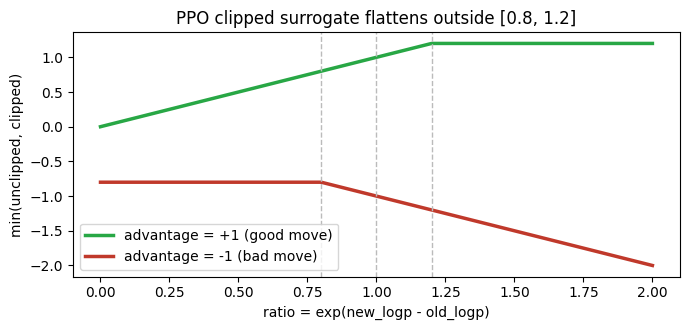

In [ ]:
ratios = np.linspace(0.0, 2.0, 400)
eps = 0.2
fig, ax = plt.subplots(figsize=(7, 3.4))
for A, color, label in [(+1.0, "#28a745", "advantage = +1 (good move)"),
                        (-1.0, "#c0392b", "advantage = -1 (bad move)")]:
    unclipped = ratios * A
    clipped   = np.clip(ratios, 1 - eps, 1 + eps) * A
    surrogate = np.minimum(unclipped, clipped)        # the PPO objective (per sample)
    ax.plot(ratios, surrogate, color=color, lw=2.5, label=label)
for xref in (1 - eps, 1.0, 1 + eps):
    ax.axvline(xref, color="#bbb", ls="--", lw=1)
ax.set_title("PPO clipped surrogate flattens outside [0.8, 1.2]")
ax.set_xlabel("ratio = exp(new_logp - old_logp)")
ax.set_ylabel("min(unclipped, clipped)")
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
# Prove it: past the clip boundary, increasing the ratio does NOT change the objective.
def surrogate(ratio, A=1.0, eps=0.2):
    return min(ratio * A, float(np.clip(ratio, 1 - eps, 1 + eps)) * A)

assert np.isclose(surrogate(1.2), surrogate(1.5))     # both capped at 1.2*A for adv > 0
assert np.isclose(surrogate(1.2), surrogate(5.0))
print("beyond ratio 1.2 the objective is flat — one rep cannot overhaul the policy ✓")


beyond ratio 1.2 the objective is flat — one rep cannot overhaul the policy ✓


### Shape trace

| Tensor | Shape |
|---|---|
| `new_logp`, `old_logp`, `adv` | `(N,)` |
| `new_values`, `old_values`, `returns` | `(N,)` |
| `ratio`, `unclipped`, `clipped` | `(N,)` |
| `policy_loss`, `value_loss`, `entropy`, `approx_kl`, `total_loss` | scalar `()` |

The three side terms: `value_loss = MSE(new_values, returns)`, `entropy = -new_logp.mean()` (approx; `ent_coef=0.0`, so off), `approx_kl = mean(old_logp − new_logp)` (logging only). Total: `policy_loss + 0.5·value_loss − 0.0·entropy`.

### Why it matters

- **Simple:** clip = "small steps only."
- **Practical:** clipping is a one-line stand-in for TRPO's heavy trust-region machinery — it's why PPO became the default RL algorithm.
- **Deeper:** the surrogate is a *lower bound* on the true objective; optimizing a bound you can't overshoot is what makes PPO stable. Part 9 reuses it verbatim.


---
## 8.6 One Full PPO Step (the Loop)

```mermaid
graph LR
    prompt["8.2 prompt<br>one instruction"]
    gen["8.2 policy does a take<br>generate + record logprobs"]
    judge["8.3 judge scores it<br>reward model r"]
    shaped["8.3 KL leash<br>r - kl * (logp - ref_logp)"]
    adv["8.4 advantage<br>actual - expected"]
    clip["8.5 clipped update<br>min(unclipped, clipped)"]
    step["8.6 one PPO step<br>backward + AdamW"]
    ev["8.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> gen --> judge --> shaped --> adv --> clip --> step --> ev
    step -. repeat .-> prompt
    ref -. KL leash .-> shaped

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style gen fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style judge fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style shaped fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style adv fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style clip fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style step fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ev fill:#e8e8e8,stroke:#bbb,color:#777
    style ref fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 6/7 memory:** Part 6's `train_sft.py` and Part 7's `train_rm.py` were *supervised* loops — fixed data, one loss, step.
>
> **Part 8 now:** the loop *generates its own data each step*: rollout → score → shape → advantage → clipped loss → backward → AdamW, updating **only the policy** (the reference and reward model never move).
>
> **Returns later:** Part 9's loop is the same skeleton with the group-baseline swap in the advantage line.

### What we're doing here, and why

One full rehearsal cycle, wired from the **real** `train_ppo.py` pieces — `model_logprobs`, the action mask, `shaped_r`, `adv`, `ppo_losses`, `backward`, `opt.step` — on tiny fresh models so it runs on CPU in seconds.

**Gotcha worth knowing — this is ONE pass, not real multi-epoch PPO.** The file's own comment admits "this step is done multiple times per batch in practice." Real PPO reuses each rollout for several inner epochs; this demo does a single forward/backward for clarity. Also: `old_logp` is **detached** (a frozen snapshot from collection), while `new_logp` is recomputed *with grad* — that difference is the entire point of the ratio.


In [ ]:
from ppo_loss import ppo_losses

# Reuse pol / ref / rm / tok from above; add an optimizer and run ONE real PPO step.
opt = torch.optim.AdamW(pol.parameters(), lr=1e-5)
kl_coef = 0.01
batch_prompts = sample_prompts(2)

# ----- COLLECT ROLLOUT (generate a take per prompt, score it) -----
pol.eval()
roll = []
for prompt in batch_prompts:
    prefix = format_prompt_only(prompt).replace("</s>", "")
    p_ids = tok.encode(prefix)[-BLK:]
    idx = torch.tensor([p_ids], dtype=torch.long)
    with torch.no_grad():
        out_ids = pol.generate(idx, max_new_tokens=16, temperature=0.7, top_k=5)[0].tolist()
    boundary = len(p_ids)
    resp_text = tok.decode(out_ids[boundary:])
    zt = torch.tensor([tok.encode(format_example(Example(prompt, resp_text)))[:BLK]], dtype=torch.long)
    with torch.no_grad():
        r_scalar = rm(zt)[0].item()
    roll.append((out_ids, boundary, r_scalar))

# ----- PAD into a batch, build the action mask and end-only reward -----
max_len = min(BLK, max(len(o[0]) for o in roll))
B = len(roll)
seq     = torch.full((B, max_len), 2, dtype=torch.long)   # PAD id = 2
mask    = torch.zeros(B, max_len, dtype=torch.bool)
rewards = torch.zeros(B, max_len)
for i, (ids, boundary, r_scalar) in enumerate(roll):
    L = min(len(ids), max_len)
    seq[i, :L] = torch.tensor(ids[:L])
    mask[i, boundary:L] = True        # response tokens are the "actions" we train on
    rewards[i, L - 1] = r_scalar       # the judge's score sits on the last token

# ----- SNAPSHOT logprobs/values at collection time (detached) -----
pol_lp = model_logprobs(pol, seq)                 # (B, max_len-1)
ref_lp = model_logprobs(ref, seq)
with torch.no_grad():
    _, values_full, _ = pol(seq, None)
values = values_full[:, :-1]
act_mask   = mask[:, 1:]                            # shift to align with logprobs
old_logp   = pol_lp[act_mask].detach()
ref_logp   = ref_lp[act_mask].detach()
old_values = values[act_mask].detach()

shaped_r = rewards[:, 1:][act_mask] - kl_coef * (old_logp - ref_logp)
returns  = shaped_r
adv      = returns - old_values
adv      = (adv - adv.mean()) / adv.std().clamp_min(1e-6)

# ----- ONE PPO UPDATE (recompute new_logp/new_values WITH grad) -----
pol.train()
logits_new, values_new_full, _ = pol(seq, None)
logp_new_all = torch.log_softmax(logits_new[:, :-1, :], dim=-1).gather(
    -1, seq[:, 1:].unsqueeze(-1)).squeeze(-1)
new_logp   = logp_new_all[act_mask]
new_values = values_new_full[:, :-1][act_mask]

out = ppo_losses(new_logp, old_logp, adv, new_values, old_values, returns,
                 clip_ratio=0.2, vf_coef=0.5, ent_coef=0.0)

w_before = pol.lm.tok_emb.weight.detach().clone()
opt.zero_grad(set_to_none=True)
out.total_loss.backward()
torch.nn.utils.clip_grad_norm_(pol.parameters(), 1.0)
opt.step()
moved = (pol.lm.tok_emb.weight.detach() - w_before).abs().sum().item()

print(f"action tokens N = {old_logp.numel()}")
print(f"total_loss {out.total_loss.item():.4f} | policy {out.policy_loss.item():.4f} "
      f"| value {out.value_loss.item():.4f} | approx_kl {out.approx_kl.item():.6f}")
print(f"policy weights moved (sum|delta| of tok_emb): {moved:.3e}   (ref + rm untouched)")
print("one real PPO step completed ✓")


action tokens N = 32
total_loss 0.0825 | policy -0.0000 | value 0.1649 | approx_kl 0.000000
policy weights moved (sum|delta| of tok_emb): 3.893e-02   (ref + rm untouched)
one real PPO step completed ✓


### Shape trace (batch of B=2)

| Tensor | Shape |
|---|---|
| `seq`, `mask`, `rewards` | `(2, max_len)` — `rewards` nonzero only at `L-1` |
| `pol_lp`, `ref_lp`, `values` | `(2, max_len-1)` |
| `act_mask` | `(2, max_len-1)` bool |
| `old_logp`, `new_logp`, `adv`, `returns` | `(N,)` — N = # action tokens |
| `out.total_loss` | scalar `()` |

### Why it matters

- **Simple:** this single cell *is* RLHF — every other section was a part of it.
- **Practical:** generate → score → update is the template every production RLHF system follows; the rest is scale and a few inner epochs.
- **Deeper:** the loop is *on-policy* — the data distribution shifts as the policy learns, which is exactly why the clip and the leash are mandatory, not optional.


---
## 8.7 Did It Improve? (Evaluation)

```mermaid
graph LR
    prompt["8.2 prompt<br>one instruction"]
    gen["8.2 policy does a take<br>generate + record logprobs"]
    judge["8.3 judge scores it<br>reward model r"]
    shaped["8.3 KL leash<br>r - kl * (logp - ref_logp)"]
    adv["8.4 advantage<br>actual - expected"]
    clip["8.5 clipped update<br>min(unclipped, clipped)"]
    step["8.6 one PPO step<br>backward + AdamW"]
    ev["8.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> gen --> judge --> shaped --> adv --> clip --> step --> ev
    step -. repeat .-> prompt
    ref -. KL leash .-> shaped

    style prompt fill:#e8e8e8,stroke:#bbb,color:#777
    style gen fill:#e8e8e8,stroke:#bbb,color:#777
    style judge fill:#e8e8e8,stroke:#bbb,color:#777
    style shaped fill:#e8e8e8,stroke:#bbb,color:#777
    style adv fill:#e8e8e8,stroke:#bbb,color:#777
    style clip fill:#e8e8e8,stroke:#bbb,color:#777
    style step fill:#e8e8e8,stroke:#bbb,color:#777
    style ev fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ref fill:#e8e8e8,stroke:#bbb,color:#777
```

> **Part 7 memory:** evaluation was *pairwise accuracy* — does the judge rank chosen above rejected?
>
> **Part 8 now:** evaluation is *average reward* — does the tuned policy earn higher judge scores than the frozen SFT reference, on held-out prompts? Higher mean reward = the rehearsal paid off.
>
> **Returns later:** Part 9 uses the same reward-delta metric; only the upstream baseline changes.

### What we're doing here, and why

After rehearsals, you check the tape: does the performer now score higher than before coaching? `eval_ppo.py` generates from both the tuned policy and the frozen reference on a fixed prompt pool and averages the judge's scores. A positive gap is the headline result of RLHF.

**Gotcha worth knowing — a hardcoded reference path.** `eval_ppo.py` loads the SFT reference from the literal string `"../part_6/runs/sft-demo/model_last.pt"`. We don't use real checkpoints here, so we build a fresh frozen reference and show the *mechanism* — generate-from-both, score-both, compare-means — not a meaningful number.


In [ ]:
# Compare avg judge reward: tuned policy (after the 8.6 step) vs the frozen reference.
def avg_reward(model, prompts):
    scores = []
    model.eval()
    for prompt in prompts:
        prefix = format_prompt_only(prompt).replace("</s>", "")
        p_ids = tok.encode(prefix)[-BLK:]
        idx = torch.tensor([p_ids], dtype=torch.long)
        with torch.no_grad():
            gen = model.generate(idx, max_new_tokens=16, temperature=0.2, top_k=5)[0].tolist()
        resp = tok.decode(gen[len(p_ids):])
        zt = torch.tensor([tok.encode(format_example(Example(prompt, resp)))[:BLK]], dtype=torch.long)
        with torch.no_grad():
            scores.append(rm(zt)[0].item())
    return sum(scores) / len(scores)

eval_prompts = sample_prompts(4)
r_policy = avg_reward(pol, eval_prompts)
r_ref    = avg_reward(ref, eval_prompts)
print(f"avg judge reward | tuned policy: {r_policy:.4f} | frozen reference: {r_ref:.4f}")
print(f"delta (policy - reference): {r_policy - r_ref:+.4f}")
print("\nWith FRESH weights this delta is noise — the point is the mechanism (generate both, score both,")
print("compare means). With orchestrator.py --demo (real SFT+RM ckpts) the delta becomes the real gain.")


avg judge reward | tuned policy: -0.0029 | frozen reference: -0.0038
delta (policy - reference): +0.0009

With FRESH weights this delta is noise — the point is the mechanism (generate both, score both,
compare means). With orchestrator.py --demo (real SFT+RM ckpts) the delta becomes the real gain.


### Why it matters

- **Simple:** higher average judge score = success.
- **Practical:** this single number is how every RLHF run is reported.
- **Deeper:** it's also where *reward hacking* shows up — a high RM score on gibberish text means the leash was too loose. Eval is your honesty check.


---
## Closing the loop

```mermaid
graph LR
    prompt["8.2 prompt<br>one instruction"]
    gen["8.2 policy does a take<br>generate + record logprobs"]
    judge["8.3 judge scores it<br>reward model r"]
    shaped["8.3 KL leash<br>r - kl * (logp - ref_logp)"]
    adv["8.4 advantage<br>actual - expected"]
    clip["8.5 clipped update<br>min(unclipped, clipped)"]
    step["8.6 one PPO step<br>backward + AdamW"]
    ev["8.7 did it improve?<br>avg RM reward"]
    ref["frozen SFT reference<br>the stay-yourself anchor"]

    prompt --> gen --> judge --> shaped --> adv --> clip --> step --> ev
    step -. repeat .-> prompt
    ref -. KL leash .-> shaped

    style prompt fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style gen fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style judge fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style shaped fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style adv fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style clip fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style step fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ev fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ref fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
```

**The one-sentence takeaway:** the policy generates, the Part-7 judge scores, and PPO nudges the policy toward higher-scoring answers — rewarding what beat expectations, in *clipped* steps, on a *KL leash* back to the SFT model. ⭐

### The whole rehearsal, in one breath

- **8.1 Performer + critic** — the LM acts; the value head guesses its own score.
- **8.2 Do a take** — generate an answer and record every move's log-prob (`old_logp`).
- **8.3 Judge + leash** — score the take, then subtract a KL penalty for drifting from the frozen SFT reference.
- **8.4 Advantage** — actual shaped reward minus the critic's guess: "better than expected?"
- **8.5 Clipped update** — push good moves up, but flatten the reward past the trust-region rail *(the one idea to remember ⭐)*.
- **8.6 One PPO step** — rollout → score → advantage → clipped loss → backward → AdamW, policy only.
- **8.7 Did it improve?** — average judge reward, tuned policy vs frozen reference.

### You now have everything needed to read every file in `part_8/`

- [policy.py](policy.py) — 8.1 the performer + critic: `GPTModern` LM + toy `Linear(vocab→1)` value head
- [rollout.py](rollout.py) — 8.2/8.3 tokenizer, `generate`, `model_logprobs`, `shift_labels`, `gather_logprobs`, `approx_kl`, `sample_prompts`
- [ppo_loss.py](ppo_loss.py) — 8.5 **the clipped surrogate + value MSE + entropy ⭐**
- [train_ppo.py](train_ppo.py) — 8.6 the on-policy PPO loop (rollout → shaped reward → advantage → clipped step)
- [eval_ppo.py](eval_ppo.py) — 8.7 average RM reward, tuned policy vs frozen SFT reference
- [orchestrator.py](orchestrator.py) — runs the two unit tests, then the optional tiny demo
- [tests/test_ppo_loss.py](tests/test_ppo_loss.py) — proves the clipped objective returns a scalar ⭐
- [tests/test_policy_forward.py](tests/test_policy_forward.py) — proves `logits (B,T,V)` and `values (B,T)` shapes

**The one-line pipeline:** `prompt → policy generates a take (+ logprobs) → reward model scores → shaped reward (− KL leash) → advantage (actual − expected) → clipped PPO loss → AdamW on the policy → repeat → eval avg reward.`

**Run the real thing** (from inside `part_8/`):

```bash
python orchestrator.py          # runs both unit tests
python orchestrator.py --demo   # tests, then a tiny PPO run + eval (needs Part 6 SFT + Part 7 RM checkpoints)
```

The demo expects `../part_6/runs/sft-demo/model_last.pt` and `../part_7/runs/rm-demo/model_last.pt`. The notebook above needs **neither** — it builds fresh tiny models so every wire is real even though the answers are gibberish.

### What's next

Part 8 closed the loop, but it carries a costly passenger — the **value head**, a second network whose only job is to guess each take's score, and a *toy* one at that (it sits on logits, not hidden states). **Part 9 begins GRPO (Group Relative Policy Optimization).** GRPO keeps the clip and the KL leash exactly as you met them here, but **deletes the critic**: instead of asking a value head "what did you expect?", it generates a *group* of takes for the same prompt and uses the **group's average reward** as the baseline. Same "better than expected?" question — answered by the peer group instead of a gut estimate. **The performer stops needing a private coach to guess scores, and starts measuring each take against the room.**
